# Example 11: Autoregressive Models

Autoregressive (AR) models feed their own predictions back as input, enabling
free-running multi-step-ahead simulation. During training, they use "teacher
forcing" (feeding true outputs), then switch to their own predictions at
inference time.

## Prerequisites

This notebook builds on concepts from Examples 00-04. Make sure you are
familiar with simulation (Example 02), prediction mode (Example 03), and
model architectures (Example 04) before proceeding.

## Setup

In [1]:
from tsfast.tsdata.benchmark import create_dls_silverbox
from tsfast.training import AR_RNNLearner, RNNLearner, AR_TCNLearner, fun_rmse

## What is Autoregressive Prediction?

In standard simulation (Example 02), the model maps input u(t) to output y(t)
in a single forward pass. In autoregressive mode:

- **Training (teacher forcing)**: the model receives `[u(t), y_true(t-1)]` as
  input. The `prediction_concat` transform (the default transform in
  `AR_RNNLearner`) concatenates the true target to the input.
- **Inference (free-running)**: the model uses its own prediction
  `[u(t), y_pred(t-1)]`. The `AR_Model` wrapper implements this feedback
  loop. This tests whether the model is stable -- errors can accumulate and
  cause divergence.

AR models are more powerful for long-horizon prediction but require stronger
regularization to stay stable.

## Load the Dataset

In [2]:
dls = create_dls_silverbox(bs=16, win_sz=500, stp_sz=10)

## Standard Simulation Baseline

Train a standard RNN for comparison. This model sees only the input u(t) and
must predict y(t) without any output feedback. It serves as a baseline to
highlight the difference autoregressive models make.

Epoch 1/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 1/10: 100%|██████████| 300/300 [00:00<00:00, 665.45it/s, train=0.0194 | valid=0.0075 | fun_rmse=0.0094]

Epoch 1/10: 100%|██████████| 300/300 [00:00<00:00, 664.92it/s, train=0.0194 | valid=0.0075 | fun_rmse=0.0094]

Epoch 2/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 2/10: 100%|██████████| 300/300 [00:00<00:00, 901.55it/s, train=0.0033 | valid=0.0018 | fun_rmse=0.0029]

...

Epoch 9/10: 100%|██████████| 300/300 [00:00<00:00, 863.02it/s, train=0.0014 | valid=0.0010 | fun_rmse=0.0022]

Epoch 10/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 10/10: 100%|██████████| 300/300 [00:00<00:00, 922.87it/s, train=0.0008 | valid=0.0008 | fun_rmse=0.0021]

Epoch 10/10: 100%|██████████| 300/300 [00:00<00:00, 921.74it/s, train=0.0008 | valid=0.0008 | fun_rmse=0.0021]

Standard RNN: (0.0008382503292523324, {'fun_rmse': 0.0020847057458013296})


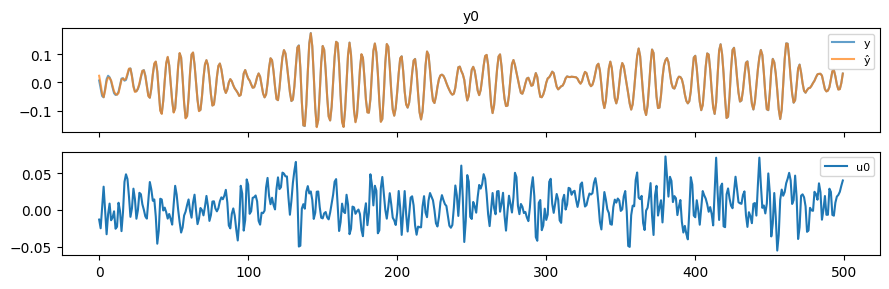

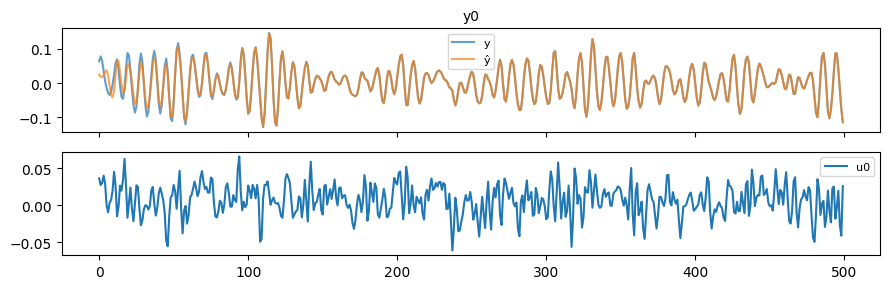

In [3]:
lrn_std = RNNLearner(dls, rnn_type='lstm', hidden_size=40, n_skip=50, metrics=[fun_rmse])
lrn_std.fit_flat_cos(n_epoch=10, lr=3e-3)
lrn_std.show_results(max_n=2)
print(f"Standard RNN: {lrn_std.validate()}")

## Autoregressive RNN

`AR_RNNLearner` wraps the model with autoregressive behavior and adds
`ActivationRegularizer` and `TemporalActivationRegularizer` automatically.
`alpha` and `beta` control activation and temporal regularization
respectively -- AR models need these for stability.

Key parameters:

- **`rnn_type='lstm'`**: use LSTM cells for the recurrent layer.
- **`hidden_size=40`**: 40 hidden units in the LSTM.
- **`alpha=1.0`**: penalty weight for large activations (AR regularization).
- **`beta=1.0`**: penalty weight for abrupt activation changes between
  timesteps (TAR regularization).

Epoch 1/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 1/10: 100%|██████████| 300/300 [00:00<00:00, 705.67it/s, train=0.0124 | valid=0.0003 | fun_rmse=0.0005]

Epoch 1/10: 100%|██████████| 300/300 [00:00<00:00, 705.09it/s, train=0.0124 | valid=0.0003 | fun_rmse=0.0005]

Epoch 2/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 2/10: 100%|██████████| 300/300 [00:00<00:00, 701.41it/s, train=0.0028 | valid=0.0002 | fun_rmse=0.0004]

...

Epoch 9/10: 100%|██████████| 300/300 [00:00<00:00, 758.94it/s, train=0.0009 | valid=0.0001 | fun_rmse=0.0001]

Epoch 10/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 10/10: 100%|██████████| 300/300 [00:00<00:00, 741.70it/s, train=0.0008 | valid=0.0000 | fun_rmse=0.0000]

Epoch 10/10: 100%|██████████| 300/300 [00:00<00:00, 741.04it/s, train=0.0008 | valid=0.0000 | fun_rmse=0.0000]

AR-RNN: (1.5940358935040422e-05, {'fun_rmse': 4.486130637815222e-05})


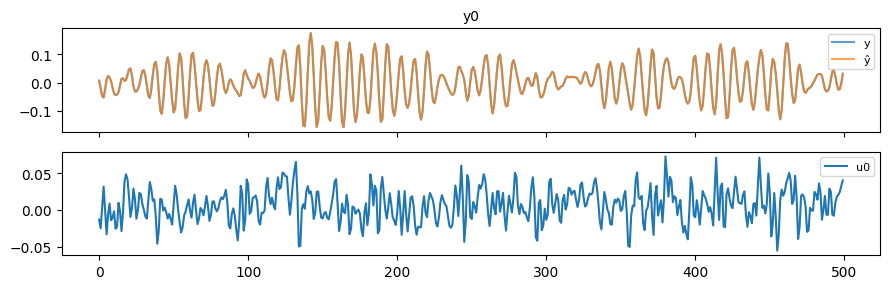

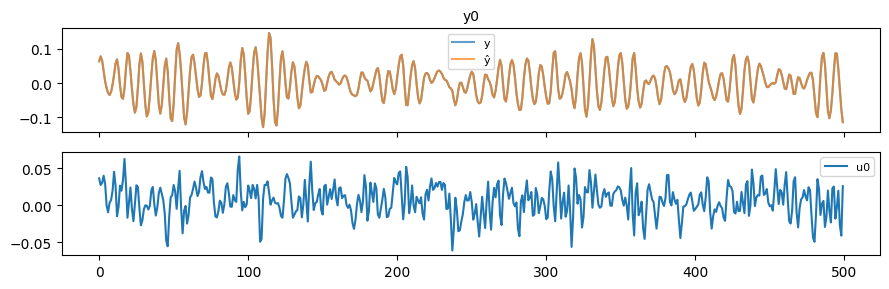

In [4]:
lrn_ar = AR_RNNLearner(
    dls, rnn_type='lstm', hidden_size=40,
    alpha=1.0, beta=1.0, metrics=[fun_rmse]
)
lrn_ar.fit_flat_cos(n_epoch=10, lr=3e-3)
lrn_ar.show_results(max_n=2)
print(f"AR-RNN: {lrn_ar.validate()}")

## Autoregressive TCN

AR mode also works with temporal convolutional networks. `AR_TCNLearner`
combines causal convolutions with autoregressive output feedback. The
`hl_depth` parameter controls the number of TCN blocks (and therefore the
receptive field, which is `2**hl_depth` timesteps).

Epoch 1/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 1/10:  97%|█████████▋| 291/300 [00:00<00:00, 581.85it/s]

Epoch 1/10: 100%|██████████| 300/300 [00:00<00:00, 581.85it/s, train=0.1456 | valid=0.0219 | fun_rmse=0.0277]

Epoch 1/10: 100%|██████████| 300/300 [00:00<00:00, 578.40it/s, train=0.1456 | valid=0.0219 | fun_rmse=0.0277]

Epoch 2/10:   0%|          | 0/300 [00:00<?, ?it/s]

...

Epoch 9/10: 100%|██████████| 300/300 [00:00<00:00, 710.94it/s, train=0.0036 | valid=0.0004 | fun_rmse=0.0005]

Epoch 10/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 10/10: 100%|██████████| 300/300 [00:00<00:00, 638.14it/s, train=0.0030 | valid=0.0003 | fun_rmse=0.0004]

Epoch 10/10: 100%|██████████| 300/300 [00:00<00:00, 637.67it/s, train=0.0030 | valid=0.0003 | fun_rmse=0.0004]

AR-TCN: (0.0002898429811466485, {'fun_rmse': 0.000445984594989568})


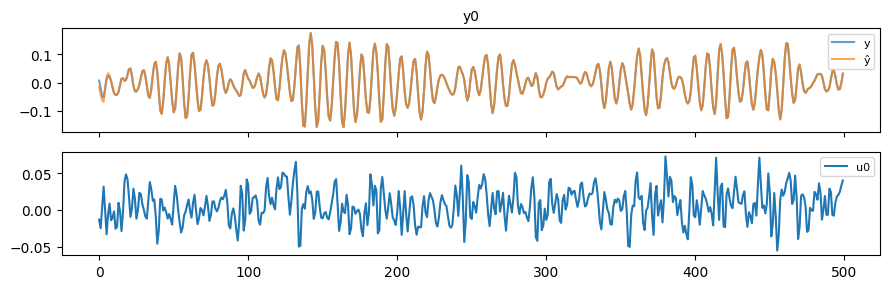

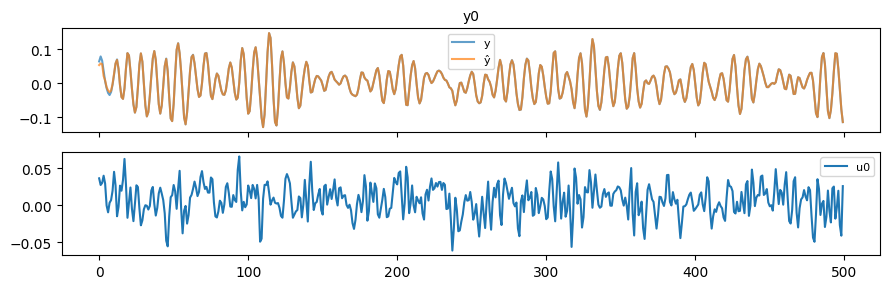

In [5]:
lrn_ar_tcn = AR_TCNLearner(dls, hl_depth=4, metrics=[fun_rmse])
lrn_ar_tcn.fit_flat_cos(n_epoch=10, lr=3e-3)
lrn_ar_tcn.show_results(max_n=2)
print(f"AR-TCN: {lrn_ar_tcn.validate()}")

## Stability and Regularization

AR models can diverge during free-running inference if prediction errors
accumulate. Regularization helps:

- **`alpha`** penalizes large activations, keeping the model in a
  well-behaved region.
- **`beta`** penalizes abrupt changes in predictions, encouraging smoothness.
- Higher `alpha` and `beta` improve stability but may reduce accuracy on
  easy regions.

Train with stronger regularization to demonstrate the trade-off:

Epoch 1/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 1/10: 100%|██████████| 300/300 [00:00<00:00, 716.43it/s, train=0.0189 | valid=0.0003 | fun_rmse=0.0006]

Epoch 1/10: 100%|██████████| 300/300 [00:00<00:00, 715.60it/s, train=0.0189 | valid=0.0003 | fun_rmse=0.0006]

Epoch 2/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 2/10: 100%|██████████| 300/300 [00:00<00:00, 722.76it/s, train=0.0043 | valid=0.0002 | fun_rmse=0.0003]

...

Epoch 9/10: 100%|██████████| 300/300 [00:00<00:00, 739.70it/s, train=0.0014 | valid=0.0001 | fun_rmse=0.0001]

Epoch 9/10: 100%|██████████| 300/300 [00:00<00:00, 739.03it/s, train=0.0014 | valid=0.0001 | fun_rmse=0.0001]

Epoch 10/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 10/10: 100%|██████████| 300/300 [00:00<00:00, 768.94it/s, train=0.0012 | valid=0.0000 | fun_rmse=0.0000]

Epoch 10/10: 100%|██████████| 300/300 [00:00<00:00, 768.15it/s, train=0.0012 | valid=0.0000 | fun_rmse=0.0000]

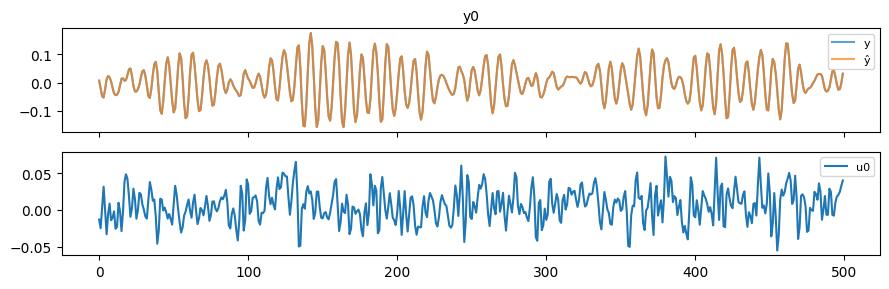

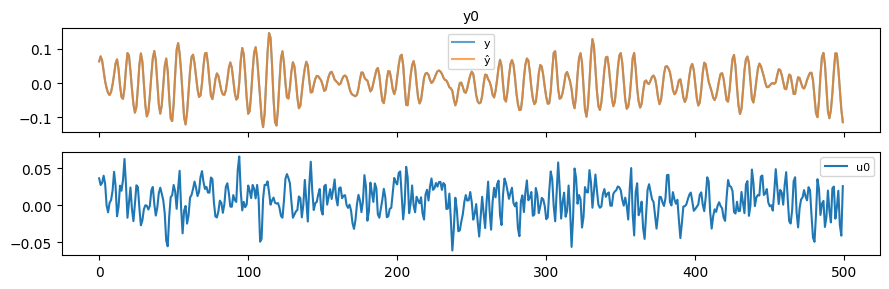

In [6]:
lrn_ar_strong = AR_RNNLearner(
    dls, rnn_type='lstm', hidden_size=40,
    alpha=3.0, beta=3.0, metrics=[fun_rmse]
)
lrn_ar_strong.fit_flat_cos(n_epoch=10, lr=3e-3)
lrn_ar_strong.show_results(max_n=2)

## Key Takeaways

- AR models feed their own predictions back as input for multi-step-ahead
  simulation.
- Teacher forcing during training provides stable gradients; free-running at
  inference tests stability.
- `AR_RNNLearner` and `AR_TCNLearner` handle the autoregressive logic
  automatically.
- Regularization (`alpha`, `beta`) is essential to prevent error accumulation
  and divergence.
- Trade-off: stronger regularization leads to more stable but potentially
  less accurate predictions.